# Mohammad Amin Kiani 4043644008
# DIP - HW2 : Morphological Operations
# ui.ac.ir 404-405

«به‌جای متلب از پایتون استفاده شده است، که همانند متلب یک محیط مناسب برای محاسبات عددی و رسم نمودار است.»

1. Dilation
2. Erosion
3. Opening
4. Closing
5. Hit-and-Miss Transform

In [18]:
# ------------------------------------------------------------
# 1) Installation note for Colab
# ------------------------------------------------------------

!pip install -q numpy matplotlib scipy imageio scikit-image pillow

In [19]:
import os
import urllib.request
import numpy as np
import imageio.v3 as iio
from scipy.ndimage import binary_dilation, binary_erosion

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.morphology import disk, binary_closing, binary_opening

from pathlib import Path
import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
from PIL import Image

from scipy import ndimage as ndi
from skimage import img_as_ubyte
from skimage.morphology import dilation, erosion, closing, opening


# ------------------------------------------------------------
# 2) Public image sources
# ------------------------------------------------------------
CIRCLES_URL = "https://raw.githubusercontent.com/camieac/image-processing-matlab/master/lab06/images/circles.png"
BLOBS_URL = "https://samples.fiji.sc/blobs.png"
SNOWFLAKES_URL = "https://raw.githubusercontent.com/skeydan/rstudio_conf_2019_eager_execution/master/snowflakes.png"
CAMERAMAN_URL = "https://raw.githubusercontent.com/androbaza/standard-test-images/main/cameraman.tif"

DATA_DIR = Path("morphology_data")
OUT_DIR = Path("morphology_outputs")
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

def download_if_needed(url: str, path: Path) -> None:
    """Download a file only if it is not already available locally."""
    if not path.exists():
        print(f"Downloading {path.name} ...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"{path.name} already exists.")

def load_images():
    """Download and load the sample images used in the exercises."""
    download_if_needed(CAMERAMAN_URL, DATA_DIR / "cameraman.tif")
    download_if_needed(CIRCLES_URL, DATA_DIR / "circles.png")
    download_if_needed(BLOBS_URL, DATA_DIR / "blobs.png")
    download_if_needed(SNOWFLAKES_URL, DATA_DIR / "snowflakes.png")

    cameraman = np.array(Image.open(DATA_DIR / "cameraman.tif").convert("L"))
    circles = np.array(Image.open(DATA_DIR / "circles.png")).astype(bool)
    blobs = np.array(Image.open(DATA_DIR / "blobs.png").convert("L"))
    snowflakes_rgb = np.array(Image.open(DATA_DIR / "snowflakes.png").convert("RGB"))
    snowflakes_gray = img_as_ubyte(rgb2gray(snowflakes_rgb))

    return cameraman, circles, blobs, snowflakes_rgb, snowflakes_gray

def save_fig(fig, name: str) -> None:
    fig.savefig(OUT_DIR / name, dpi=200, bbox_inches="tight")
    plt.close(fig)

# ------------------------------------------------------------
# Exercise 1: Dilation
# ------------------------------------------------------------
def build_dilation_image(seed: int) -> np.ndarray:
    """Replicate the MATLAB synthetic binary image with a fixed seed."""
    rng = np.random.default_rng(seed)
    B = np.zeros((256, 256), dtype=bool)

    # MATLAB: for i=128:160, for j=128:160, B(i,j)=1
    B[127:160, 127:160] = True

    # MATLAB: for i=20:25, for j=30:190, B(i,j)=1
    B[19:25, 29:190] = True

    # MATLAB random pixels; Python uses 0-based indexing.
    coords = np.floor(rng.random((40, 2)) * 255).astype(int)
    B[coords[:, 0], coords[:, 1]] = True
    return B

def run_dilation_experiment(seed: int):
    B = build_dilation_image(seed)
    kernels = [3, 5, 7, 9]
    outs = [dilation(B, footprint=np.ones((k, k), dtype=bool)) for k in kernels]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(B, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Original image\n(seed={seed})")
    axes[0].axis("off")
    for ax, out, k in zip(axes[1:], outs, kernels):
        ax.imshow(out, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Dilated image\nwith {k}x{k}")
        ax.axis("off")
    plt.tight_layout()
    save_fig(fig, f"dilation_run_{seed}.png")
    return B, outs

# ------------------------------------------------------------
# Exercise 2: Erosion
# ------------------------------------------------------------
def run_erosion_experiment(cameraman: np.ndarray):
    B = (cameraman.astype(np.float32) / 255.0) > 0.3
    kernels = [3, 5, 7, 9]
    outs = [erosion(B, footprint=np.ones((k, k), dtype=bool)) for k in kernels]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(B, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Original binary image")
    axes[0].axis("off")
    for ax, out, k in zip(axes[1:], outs, kernels):
        ax.imshow(out, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Eroded image\nwith {k}x{k}")
        ax.axis("off")
    plt.tight_layout()
    save_fig(fig, "erosion_results.png")
    return B, outs

# ------------------------------------------------------------
# Exercise 3: Closing
# ------------------------------------------------------------
def run_closing_experiment(circles: np.ndarray):
    closed = closing(circles, footprint=disk(10))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(circles, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Original circles image")
    axes[0].axis("off")
    axes[1].imshow(closed, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Closed image with disk r=10")
    axes[1].axis("off")
    plt.tight_layout()
    save_fig(fig, "closing_results.png")
    return closed

# ------------------------------------------------------------
# Exercise 4: Hit-and-Miss Transform
# ------------------------------------------------------------
def run_hit_or_miss_experiment():
    bw = np.array(
        [
            [0, 0, 0, 0, 0, 0],
            [0, 0, 1, 1, 0, 0],
            [0, 1, 1, 1, 1, 0],
            [0, 1, 1, 1, 1, 0],
            [0, 0, 1, 1, 0, 0],
            [0, 0, 1, 0, 0, 0],
        ],
        dtype=bool,
    )
    interval = np.array(
        [
            [0, -1, -1],
            [1, 1, -1],
            [0, 1, 0],
        ]
    )
    bw2 = ndi.binary_hit_or_miss(
        bw, structure1=(interval == 1), structure2=(interval == -1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(bw, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input bw")
    axes[0].axis("off")
    axes[1].imshow(bw2, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("bwhitmiss result")
    axes[1].axis("off")
    plt.tight_layout()
    save_fig(fig, "hitmiss_results.png")
    return bw, interval, bw2

# ------------------------------------------------------------
# Exercise 5: Opening
# ------------------------------------------------------------
def run_opening_experiment(blobs: np.ndarray, snowflakes_gray: np.ndarray, snowflakes_rgb: np.ndarray):
    open_blobs = opening(blobs, footprint=disk(5))
    open_snow = opening(snowflakes_gray, footprint=disk(5))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].imshow(blobs, cmap="gray")
    axes[0, 0].set_title("Original blobs")
    axes[0, 0].axis("off")
    axes[0, 1].imshow(open_blobs, cmap="gray")
    axes[0, 1].set_title("Opened blobs (disk r=5)")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(snowflakes_gray, cmap="gray")
    axes[1, 0].set_title("Original snowflakes")
    axes[1, 0].axis("off")
    axes[1, 1].imshow(open_snow, cmap="gray")
    axes[1, 1].set_title("Opened snowflakes (disk r=5)")
    axes[1, 1].axis("off")
    plt.tight_layout()
    save_fig(fig, "opening_results.png")
    return open_blobs, open_snow

In [5]:
def main():
    cameraman, circles, blobs, snowflakes_rgb, snowflakes_gray = load_images()

    # Dilation is stochastic, so we run it 3 times with different seeds.
    for seed in [7, 42, 2025]:
        run_dilation_experiment(seed)

    run_erosion_experiment(cameraman)
    run_closing_experiment(circles)
    run_hit_or_miss_experiment()
    run_opening_experiment(blobs, snowflakes_gray, snowflakes_rgb)

    print(f"All figures saved into: {OUT_DIR.resolve()}")

if __name__ == "__main__":
    main()

All figures saved into: /content/morphology_outputs


Output files

The code saves figures to `morphology_outputs/`:

- `dilation_run_7.png`
- `dilation_run_42.png`
- `dilation_run_2025.png`
- `erosion_results.png`
- `closing_results.png`
- `hitmiss_results.png`
- `opening_results.png`

View the generated figures

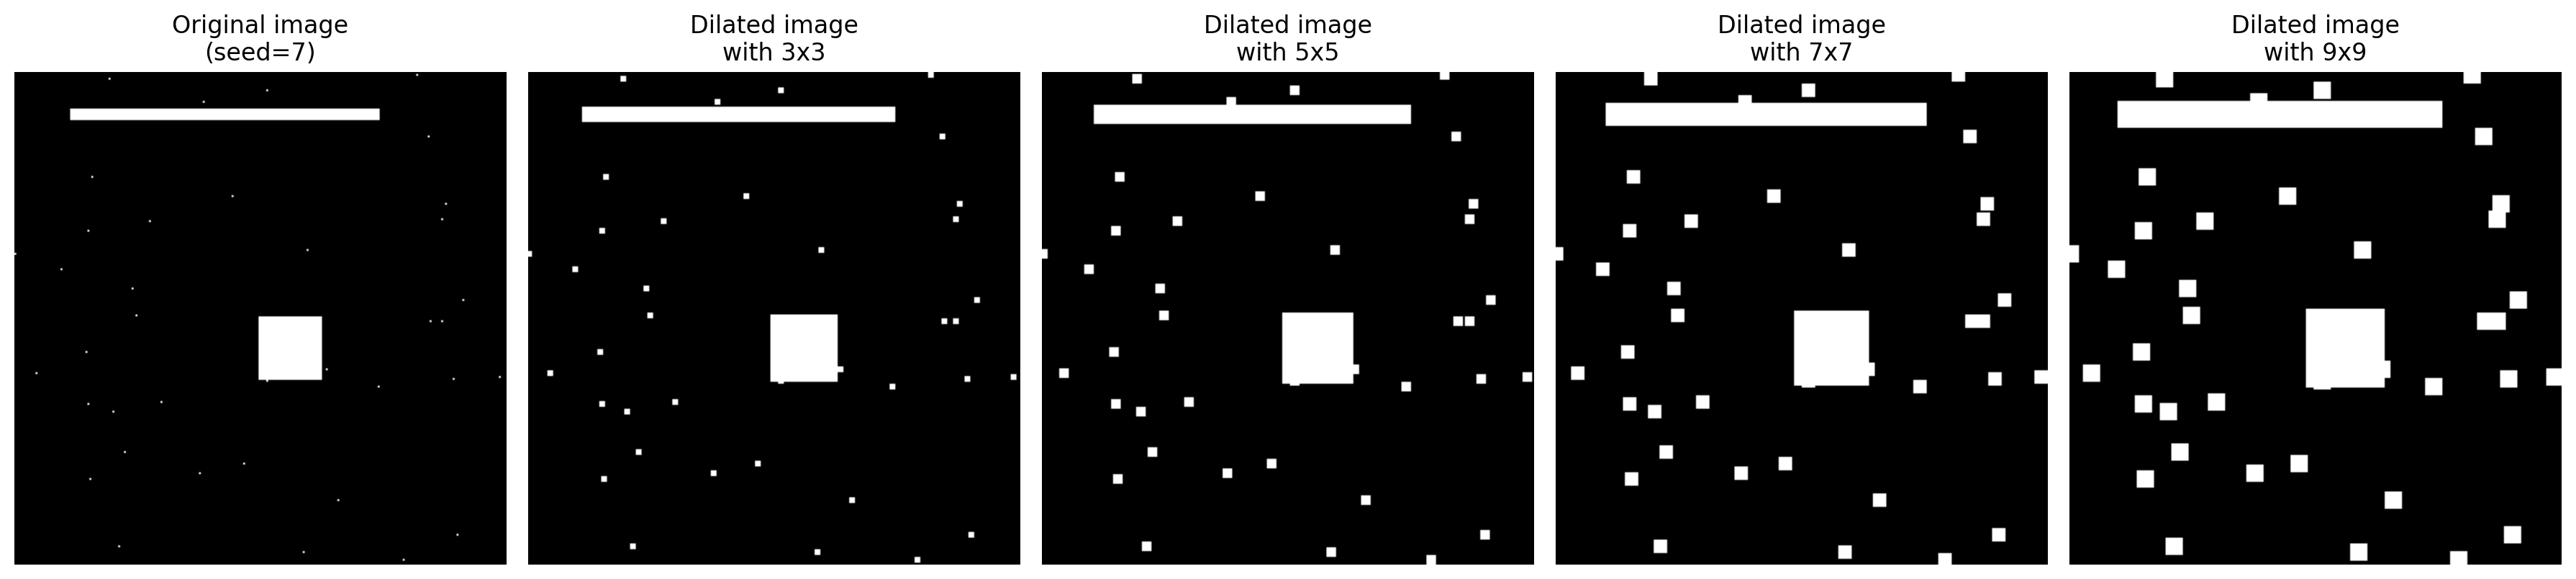

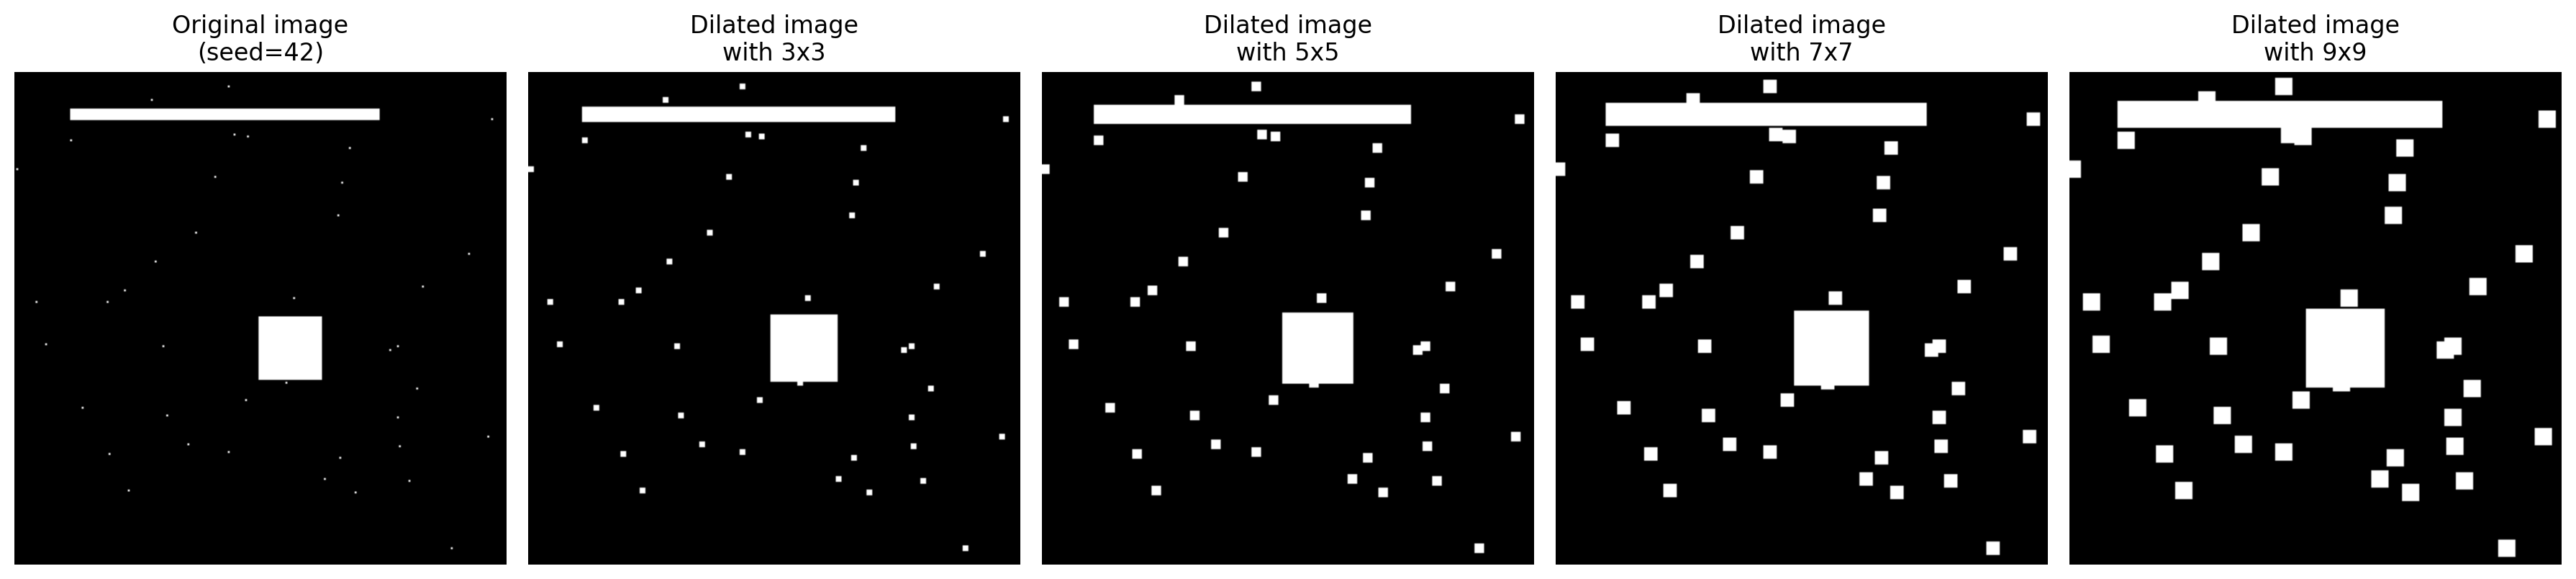

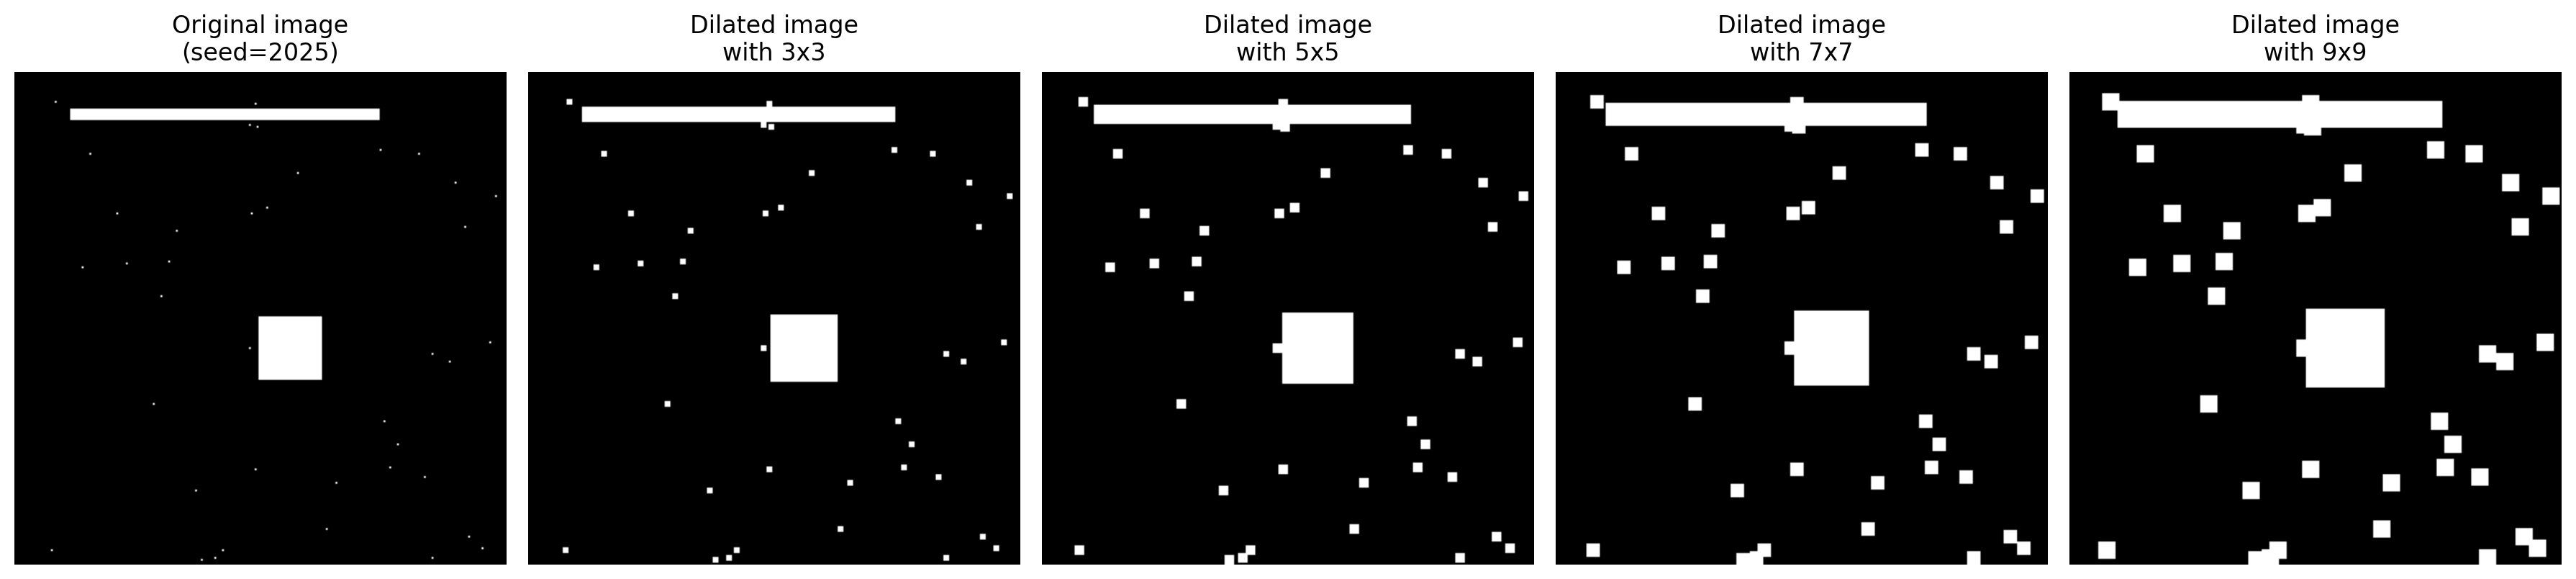

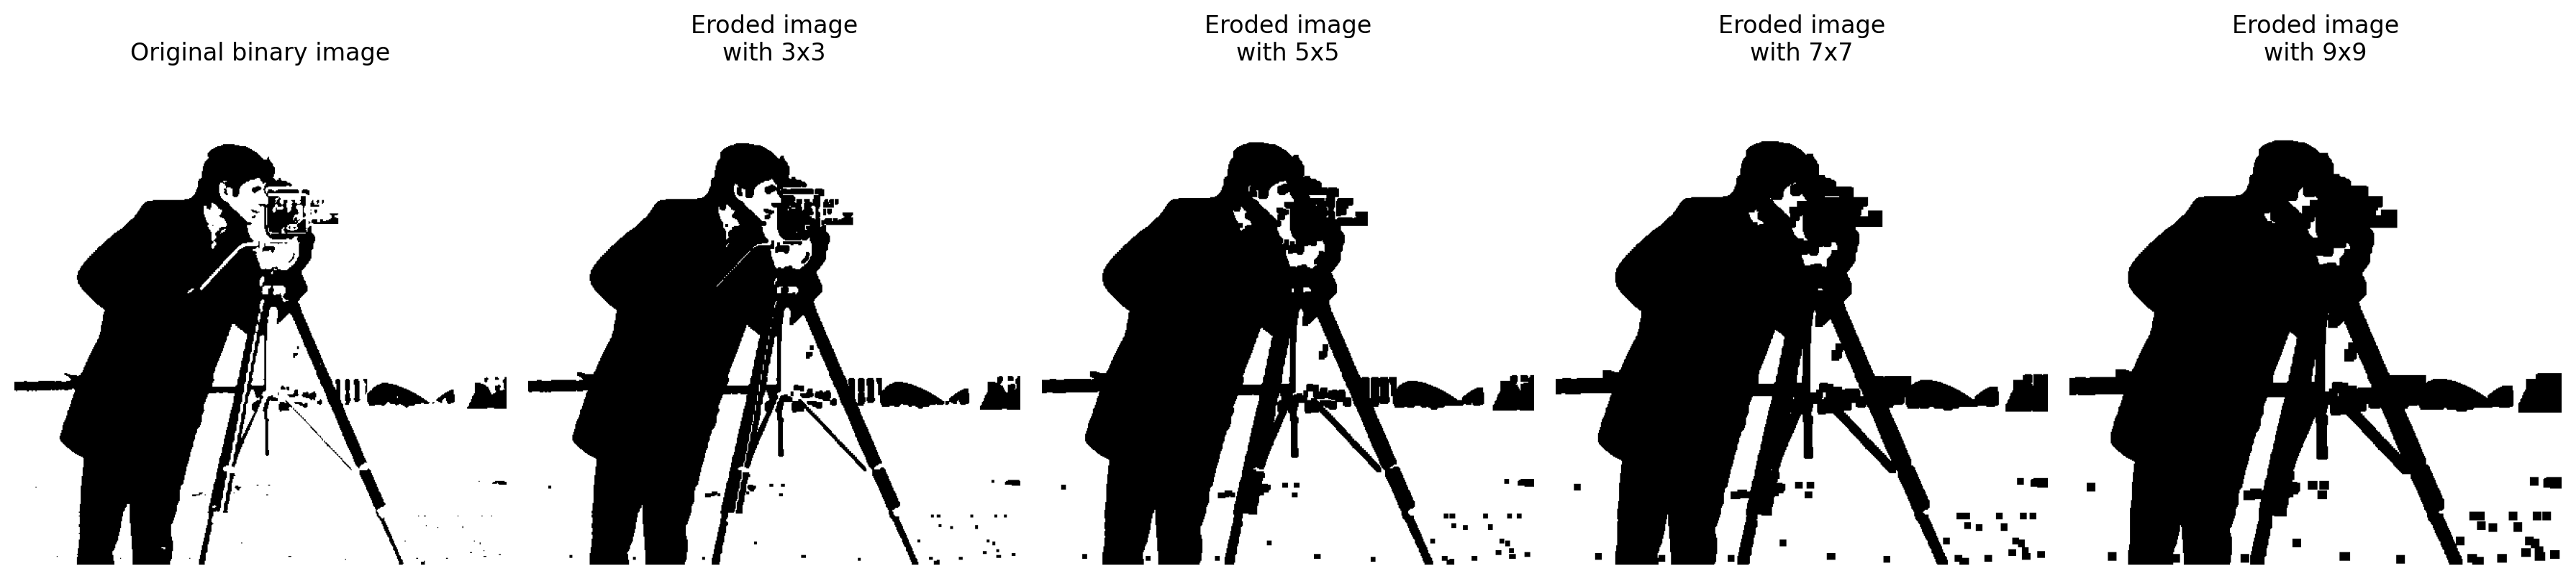

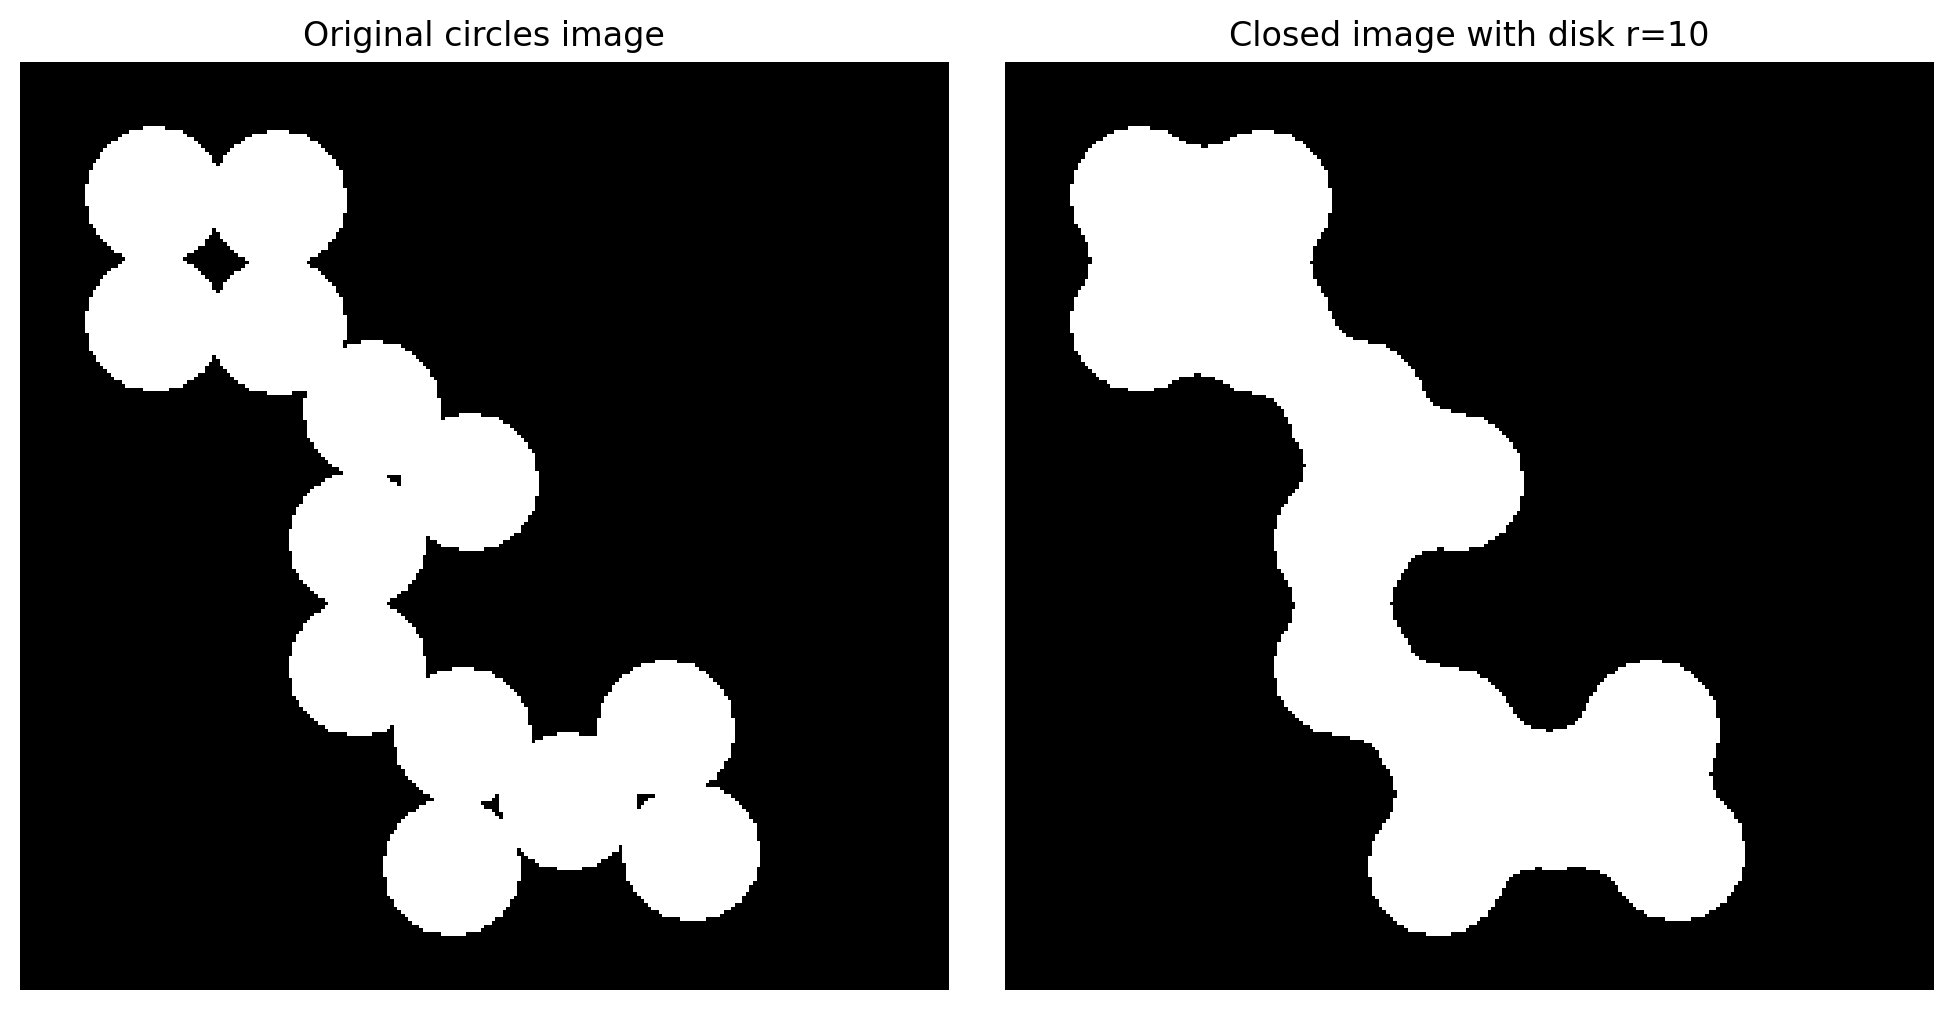

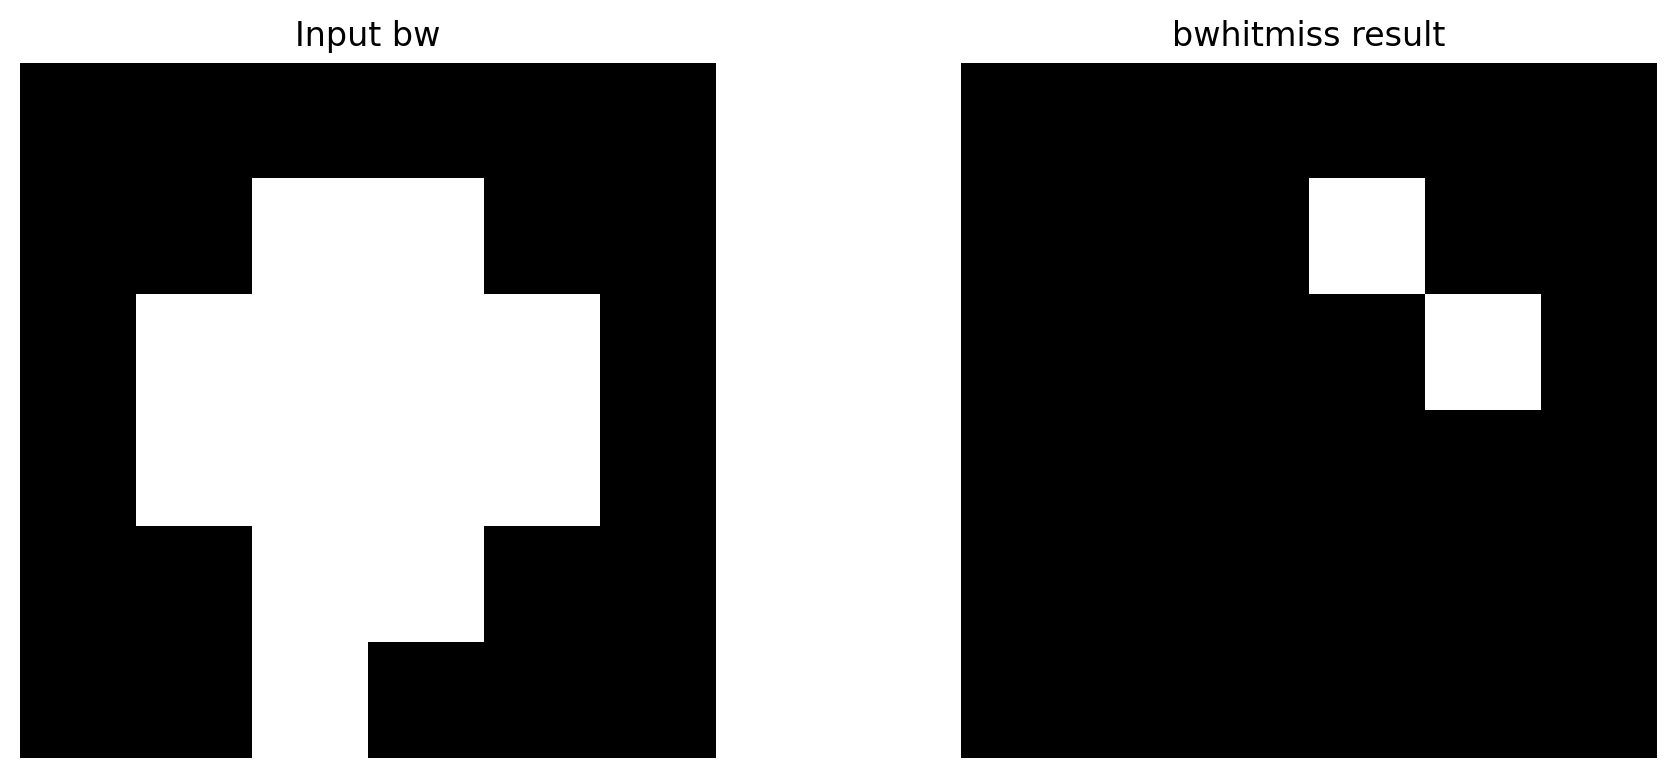

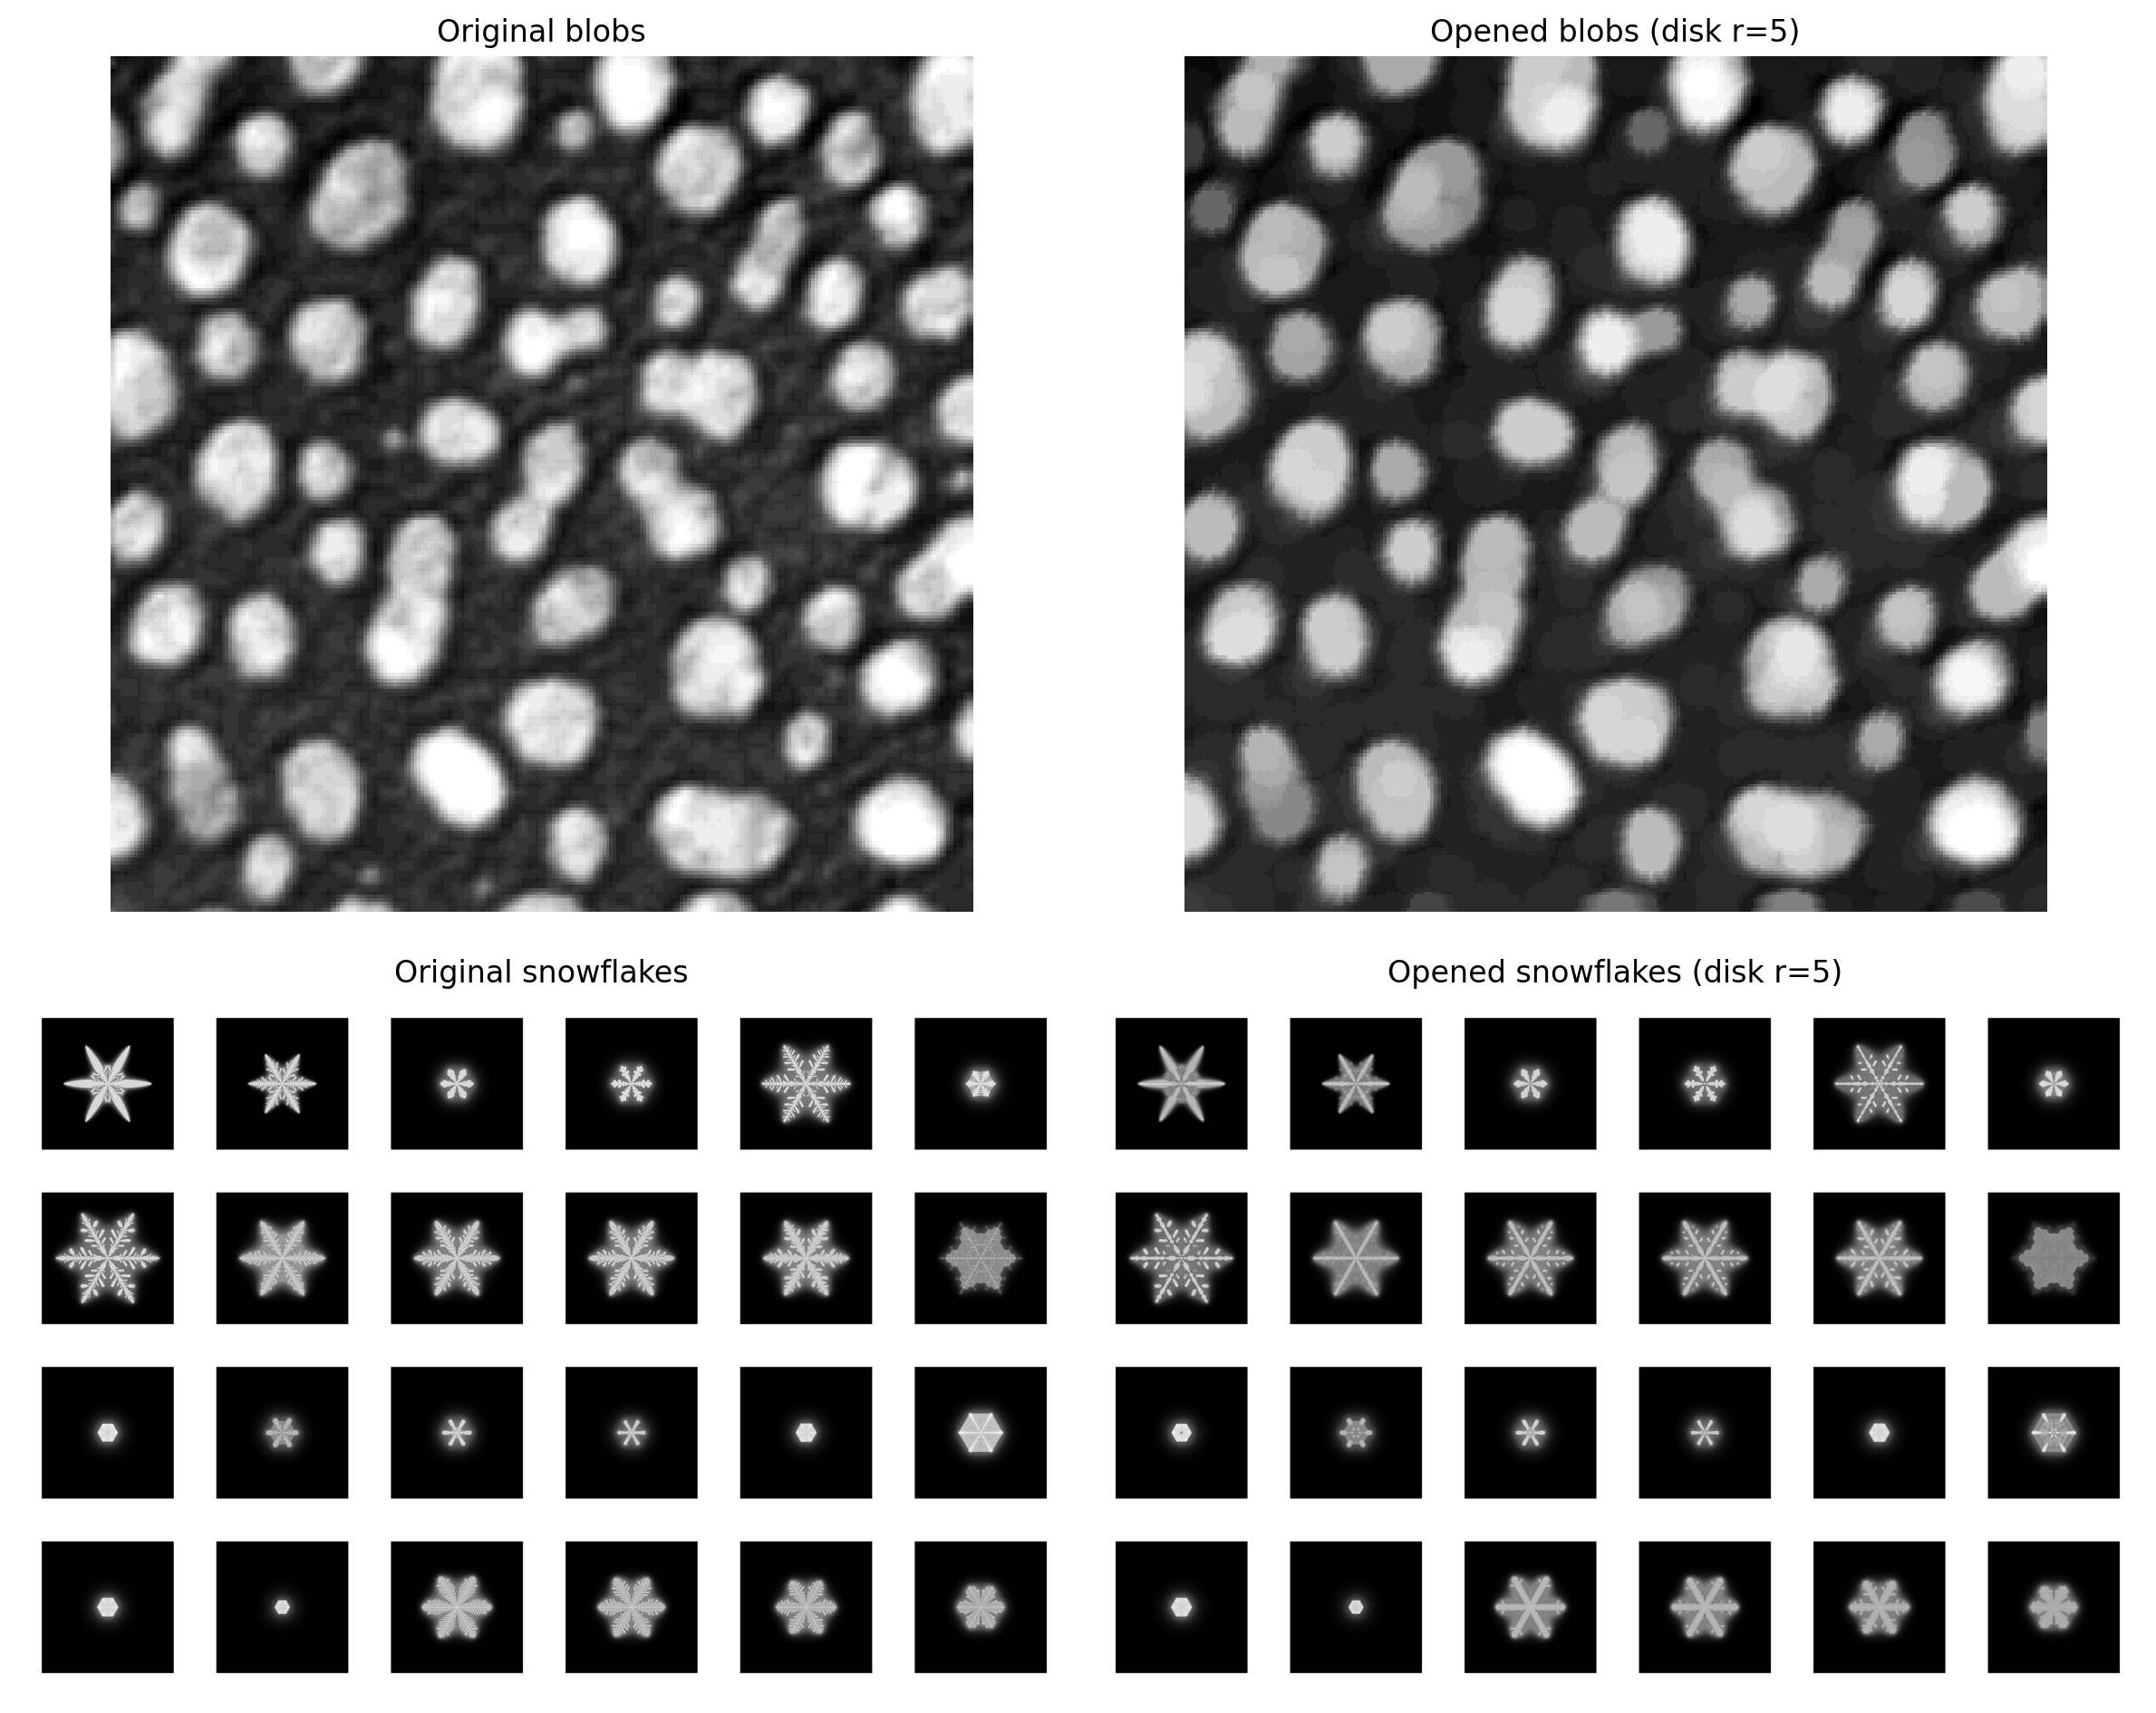

In [6]:

from IPython.display import Image, display

for name in [
    "dilation_run_7.png",
    "dilation_run_42.png",
    "dilation_run_2025.png",
    "erosion_results.png",
    "closing_results.png",
    "hitmiss_results.png",
    "opening_results.png",
]:
    display(Image(filename=str(OUT_DIR / name)))

## MorphExample01 سه بار اجرا

به دلیل تصادفی بودن 40 پیکسل، سه بار اجرا نتیجه‌های متفاوت می‌دهد.

Run 1


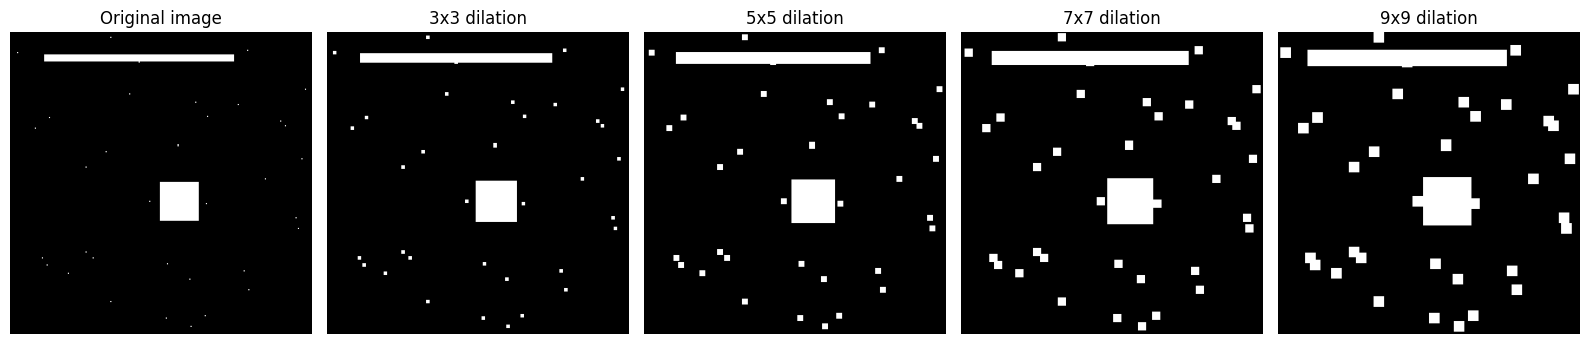

Run 2


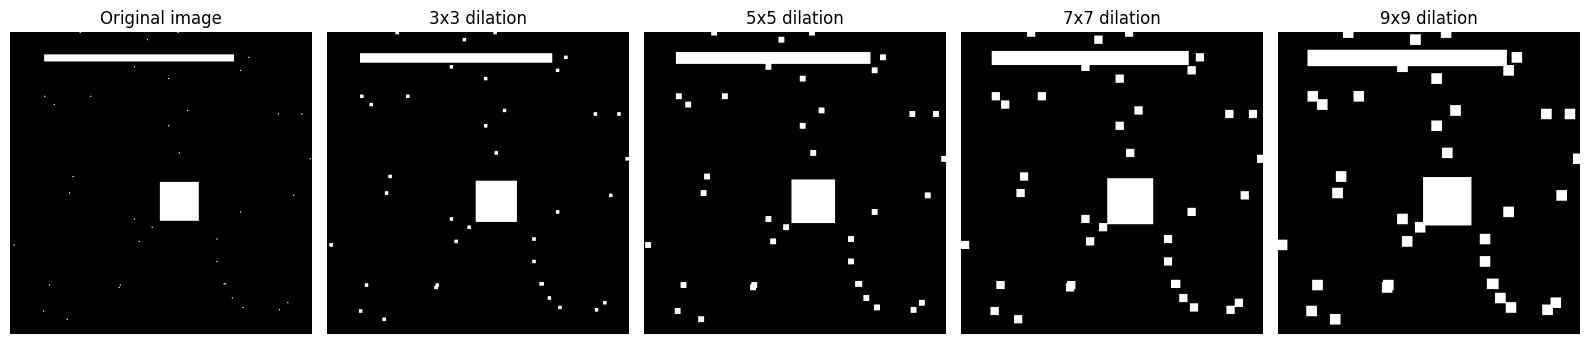

Run 3


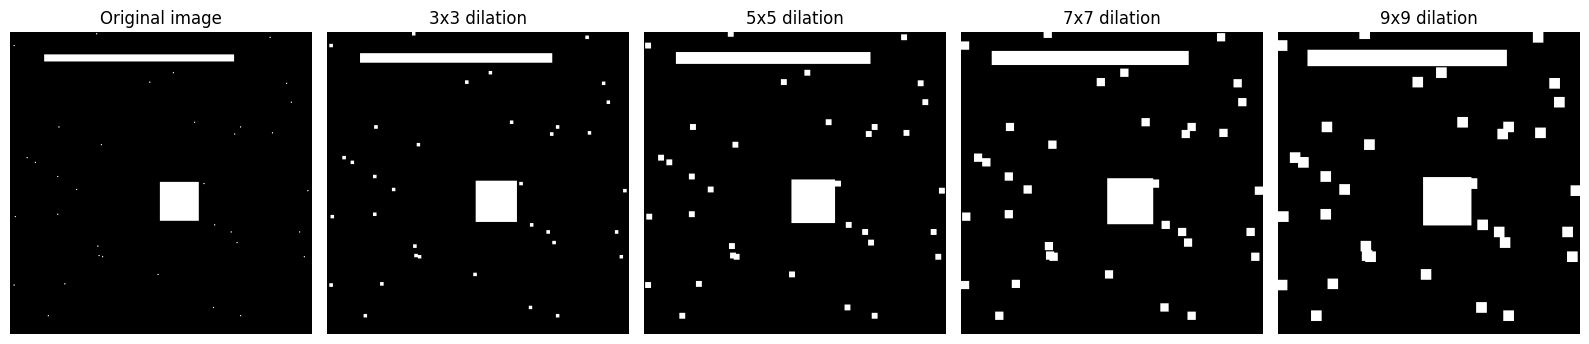

In [ ]:
for i in range(3):
    print(f"Run {i+1}")
    B, dilated = morph_example01(seed=None)


## MorphExample02 یک بار اجرا

تصویر `cameraman.tif` به‌صورت خودکار دانلود می‌شود (اگر در محیط وجود نداشته باشد)، سپس با آستانه 0.3 باینری شده و erosion روی آن اعمال می‌گردد.

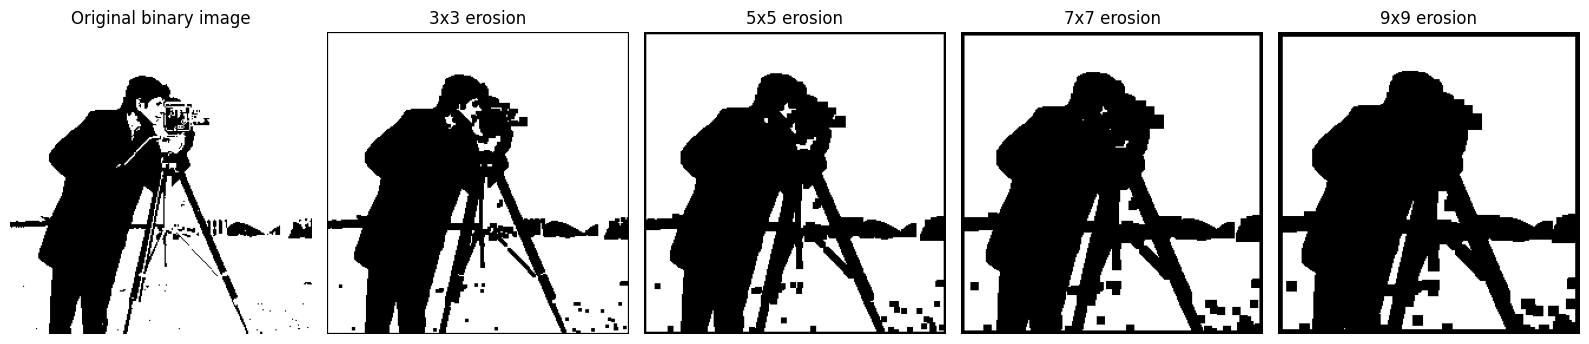

In [ ]:
I, B2, eroded = morph_example02()


## MorphExample03 دو بار اجرا

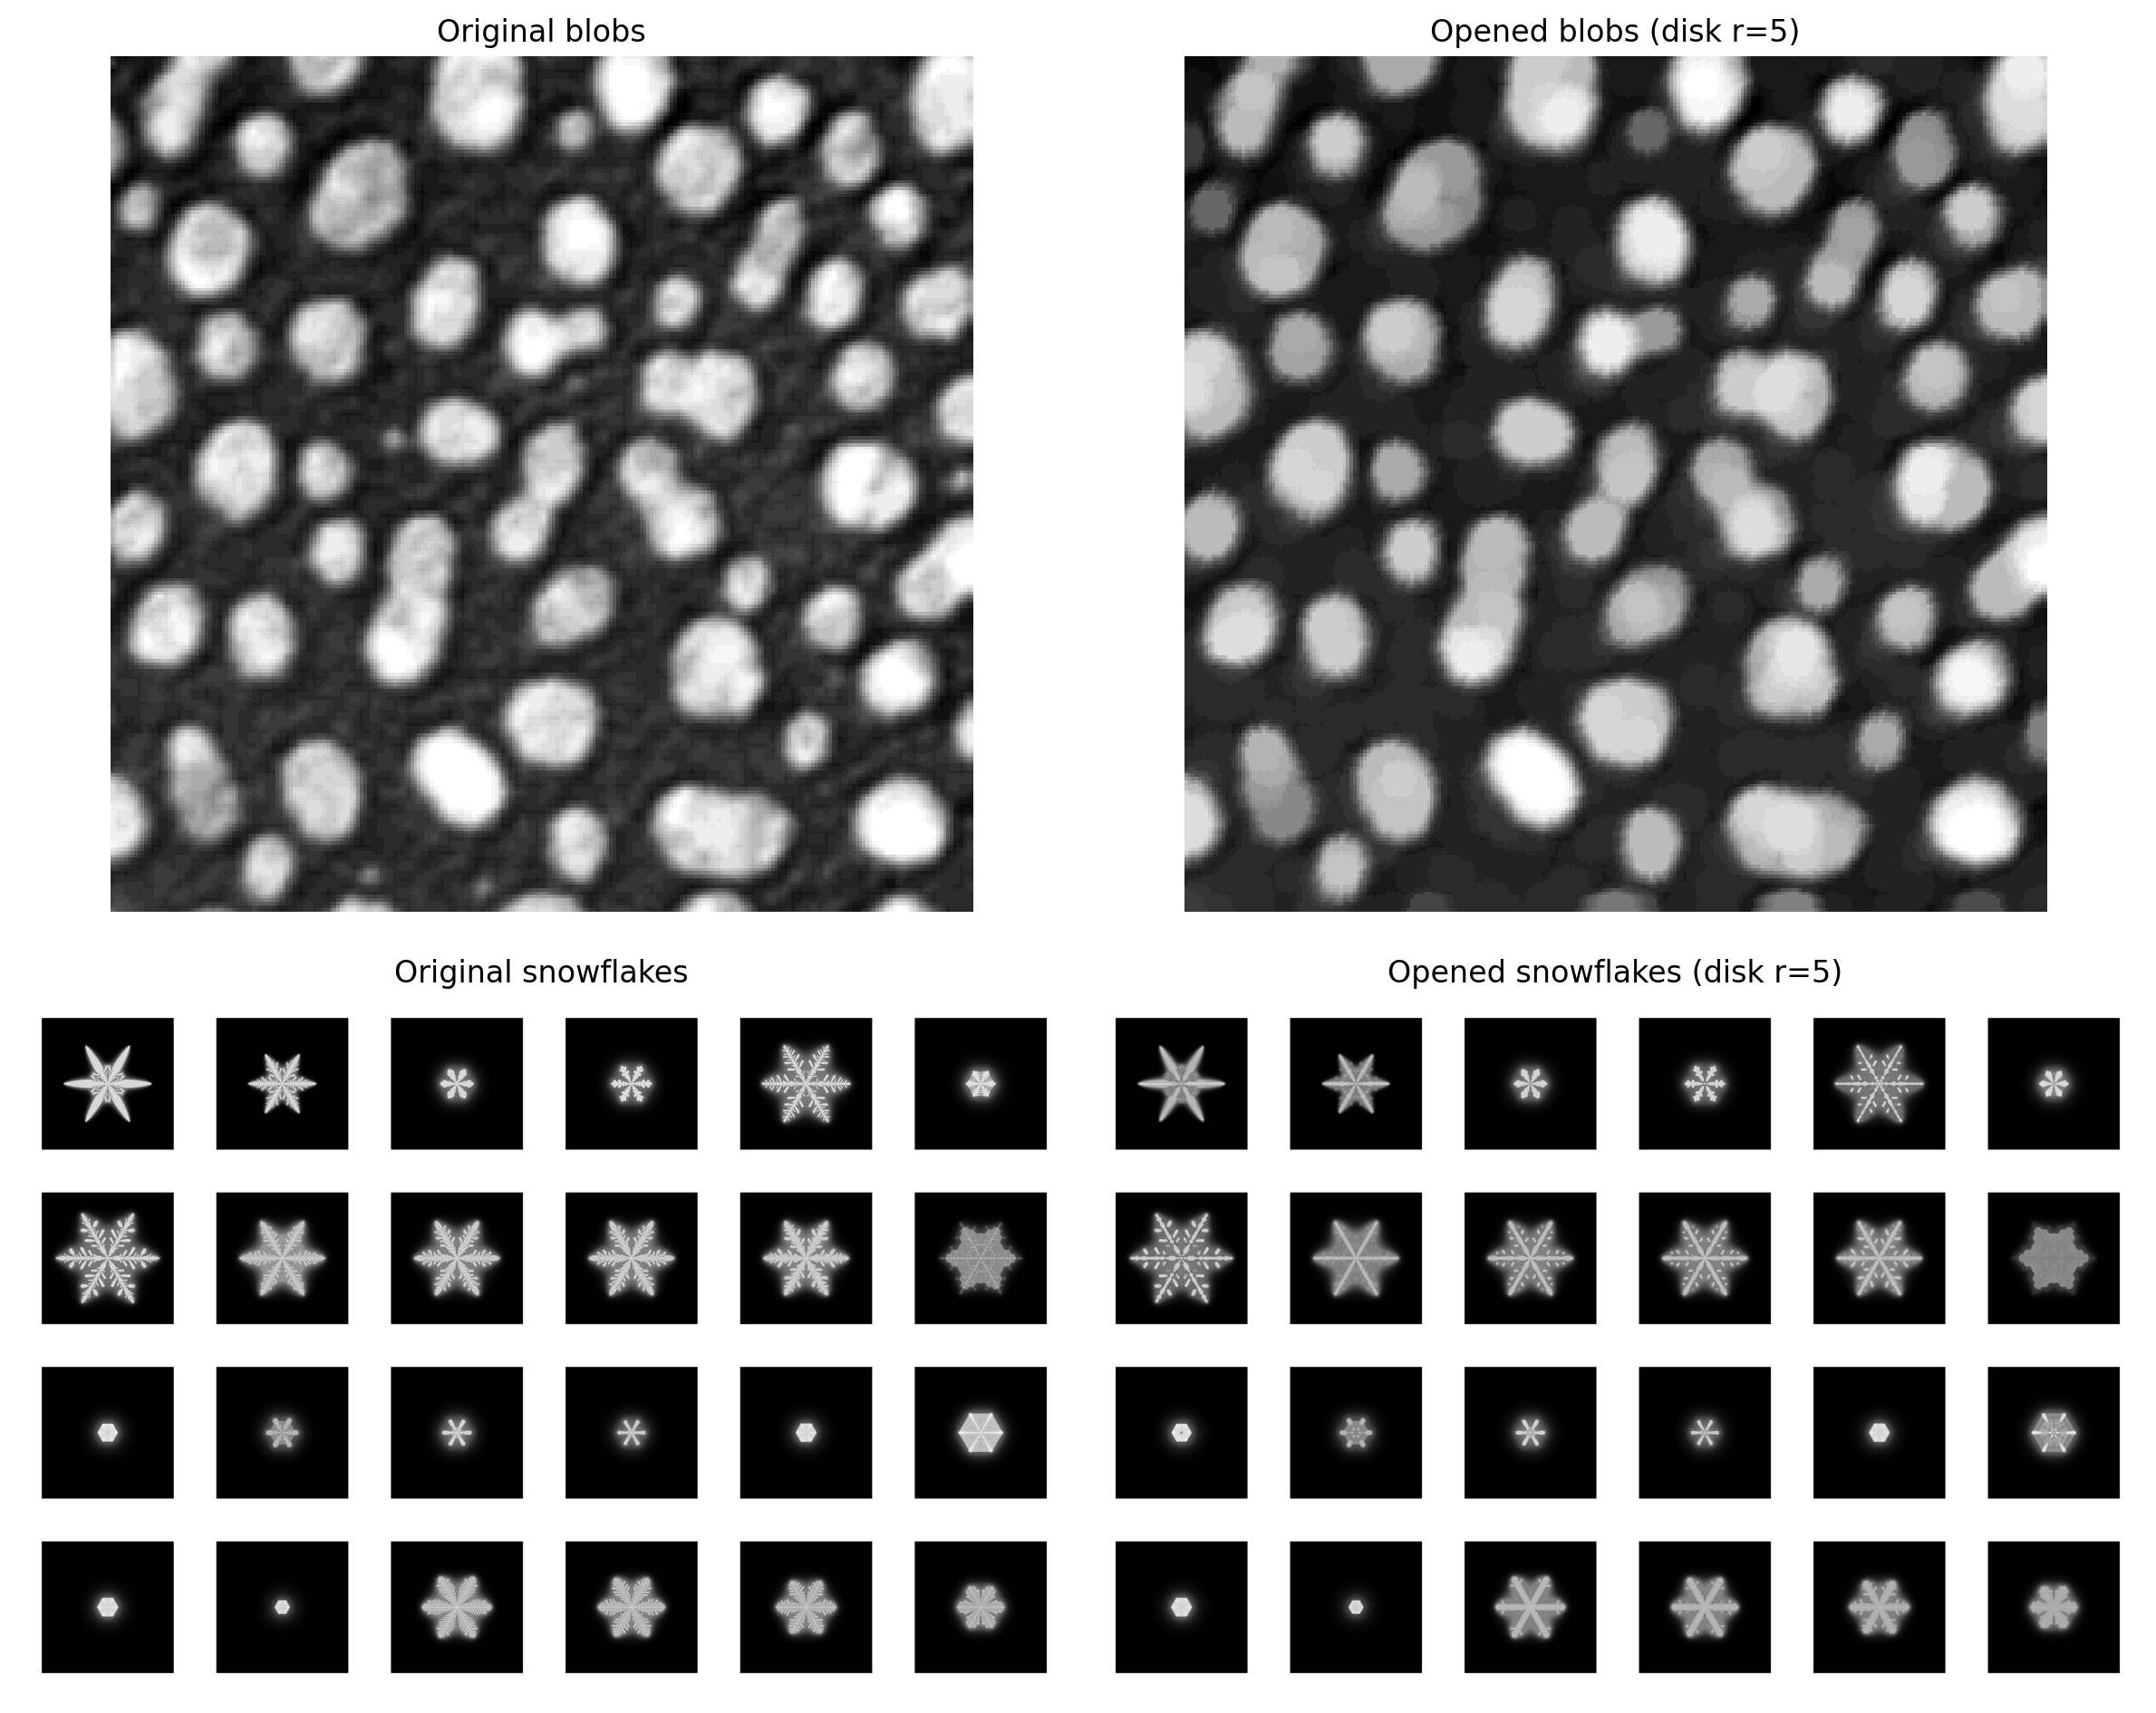

In [20]:

from IPython.display import Image, display

for name in [
    "opening_results.png",
]:
    display(Image(filename=str(OUT_DIR / name)))

## MorphExample04 دو بار اجرا

In [ ]:

from IPython.display import Image, display

for name in [
    "closing_results.png",
]:
    display(Image(filename=str(OUT_DIR / name)))

## MorphExample05 یک بار اجرا

The ternary `interval` matrix uses:
- `1`  for required foreground,
- `-1` for required background,
- `0`  for don't care.

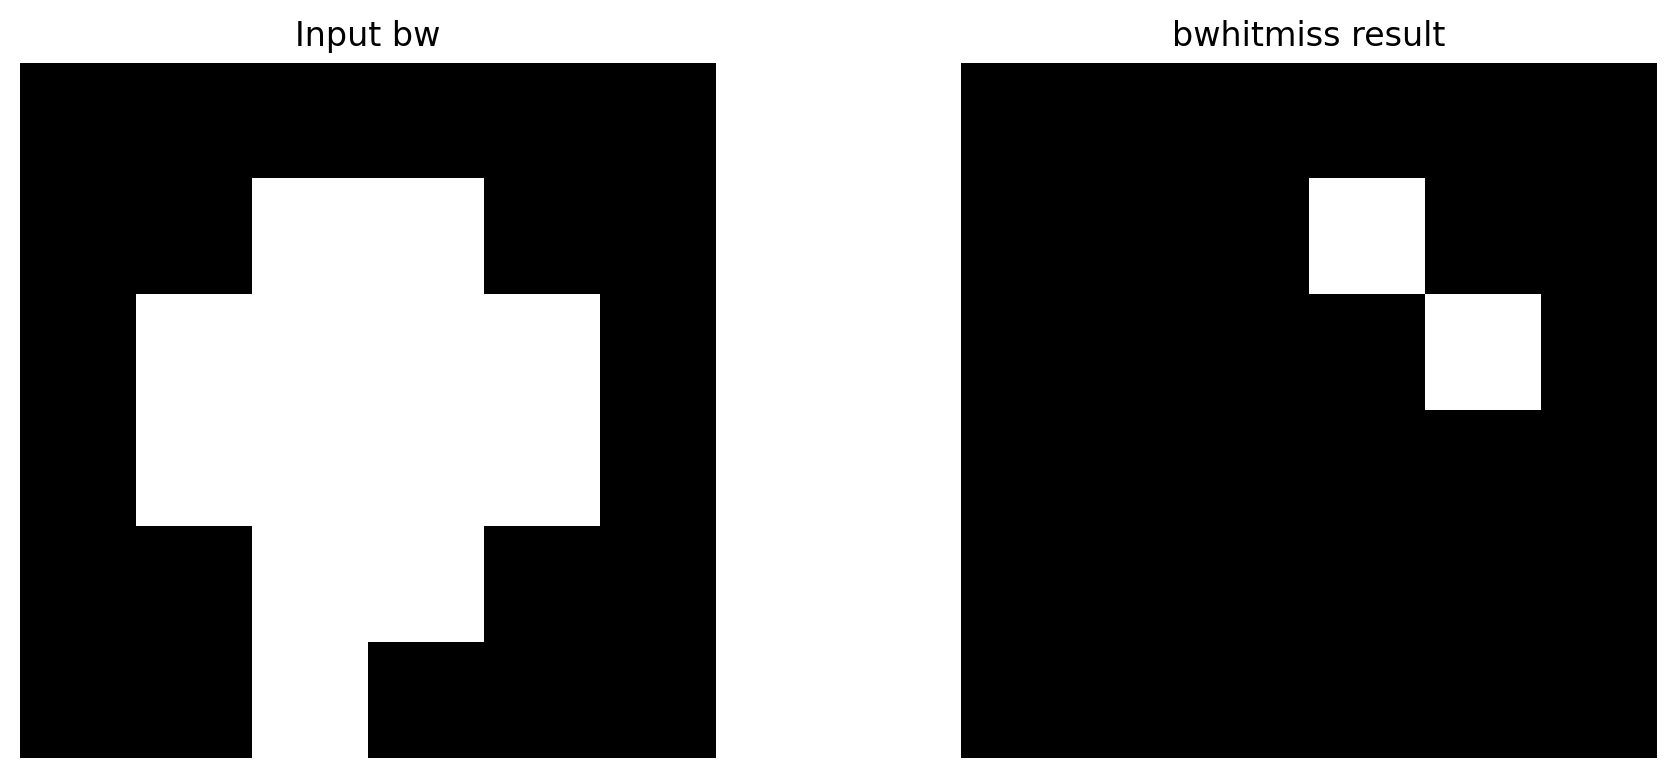

In [22]:

from IPython.display import Image, display

for name in [
    "hitmiss_results.png",
]:
    display(Image(filename=str(OUT_DIR / name)))